# Дополнительные задания 1–3

Базовое R₀, эмпирический порог эпидемии и различия между городами.

## Окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Задание 1: теория и базовый опыт

In [2]:
baseline =
    CSV.read(datafile("sir_run_basic", "trajectory.csv"), DataFrame)
R0 = 0.5 * 14
baseline_peak = maximum(baseline.infected ./ baseline.total)
comparison = DataFrame(
    beta = [0.5],
    gamma = [1/14],
    R0 = [R0],
    observed_peak = [baseline_peak],
)
CSV.write(
    datafile("sir_extra_1_2_3", "baseline_comparison.csv"),
    comparison,
)
display(comparison)

Row,beta,gamma,R0,observed_peak
,Float64,Float64,Float64,Float64
1,0.5,0.0714286,7.0,1.0


## Задание 2: порог по среднему пику трёх прогонов

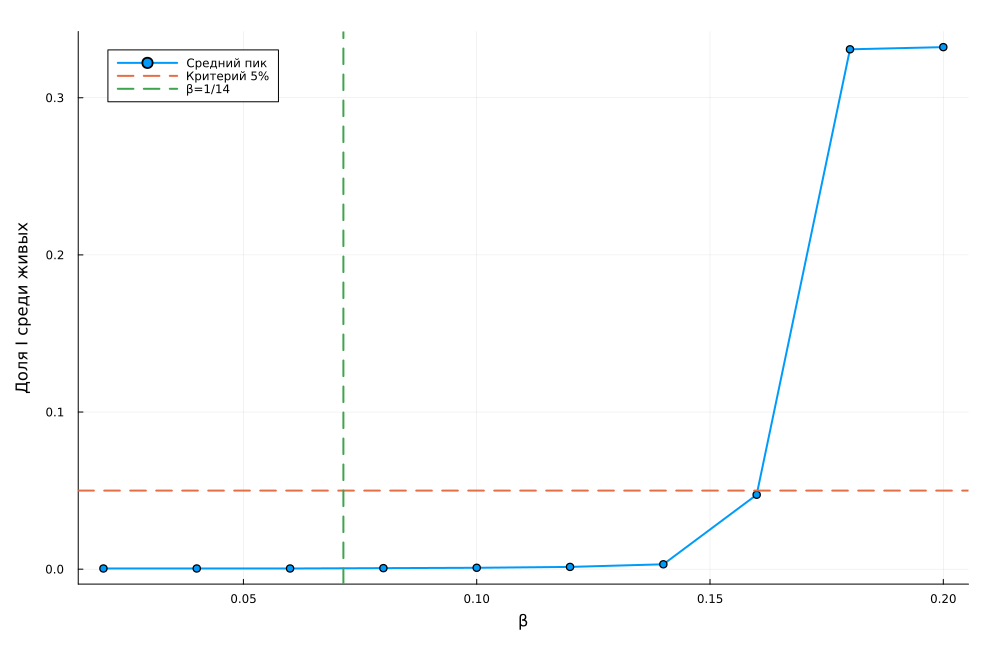

Row,theoretical,empirical_grid,grid_step
,Float64,Float64,Float64
1,0.0714286,0.18,0.02


In [3]:
threshold_scan =
    beta_scan("sir_extra_1_2_3/threshold"; betas = 0.02:0.02:0.20)
table = threshold_scan.grouped
above = table.beta[table.peak .> 0.05]
empirical = isempty(above) ? NaN : minimum(above)
thresholds = DataFrame(
    theoretical = [1/14],
    empirical_grid = [empirical],
    grid_step = [0.02],
)
CSV.write(datafile("sir_extra_1_2_3", "threshold.csv"), thresholds)
figure = plot(
    table.beta,
    table.peak;
    label = "Средний пик",
    marker = :circle,
    xlabel = "β",
    ylabel = "Доля I среди живых",
)
hline!(figure, [0.05]; label = "Критерий 5%", linestyle = :dash)
vline!(figure, [1/14]; label = "β=1/14", linestyle = :dash)
savefig(figure, imagefile("10-plot.png"))
display(figure)
display(thresholds)

## Задание 3: гетерогенная заразность

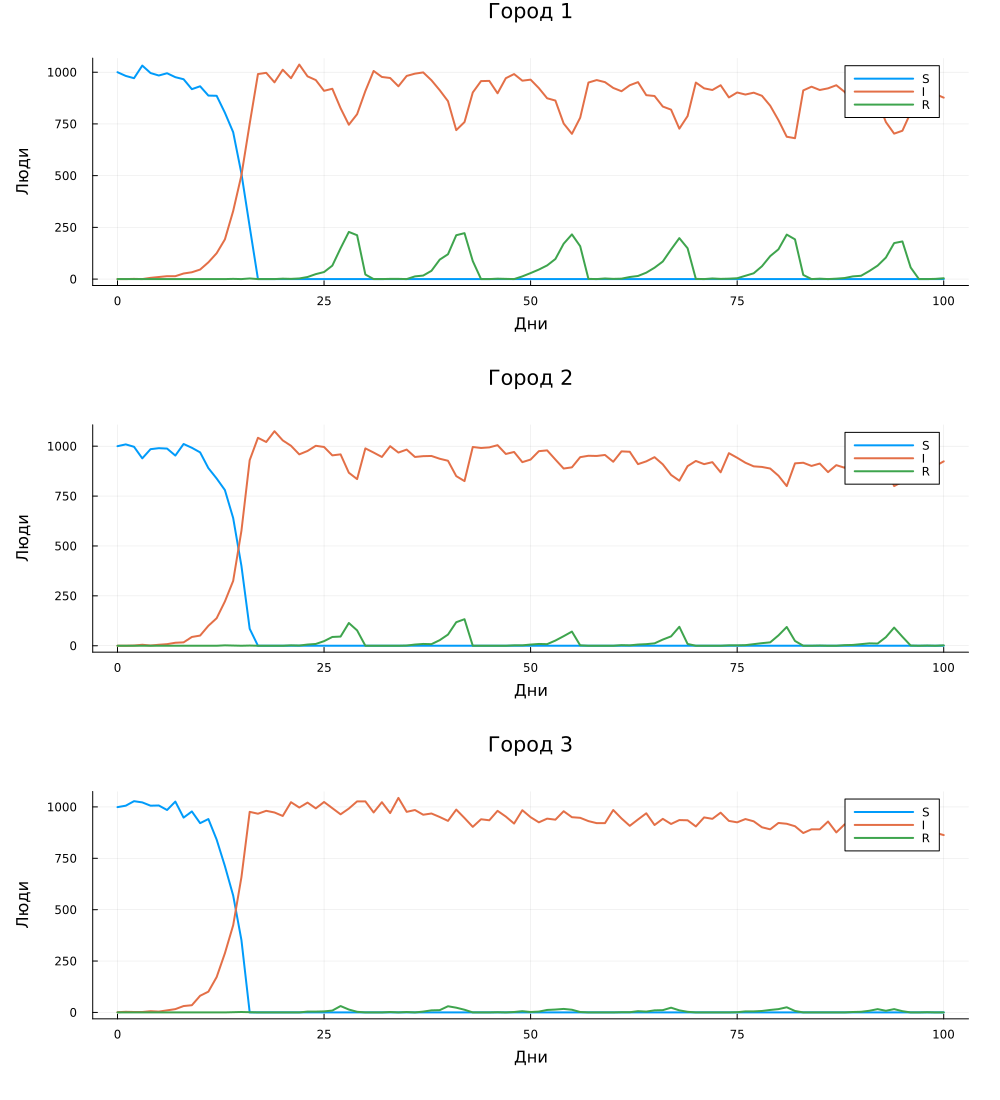

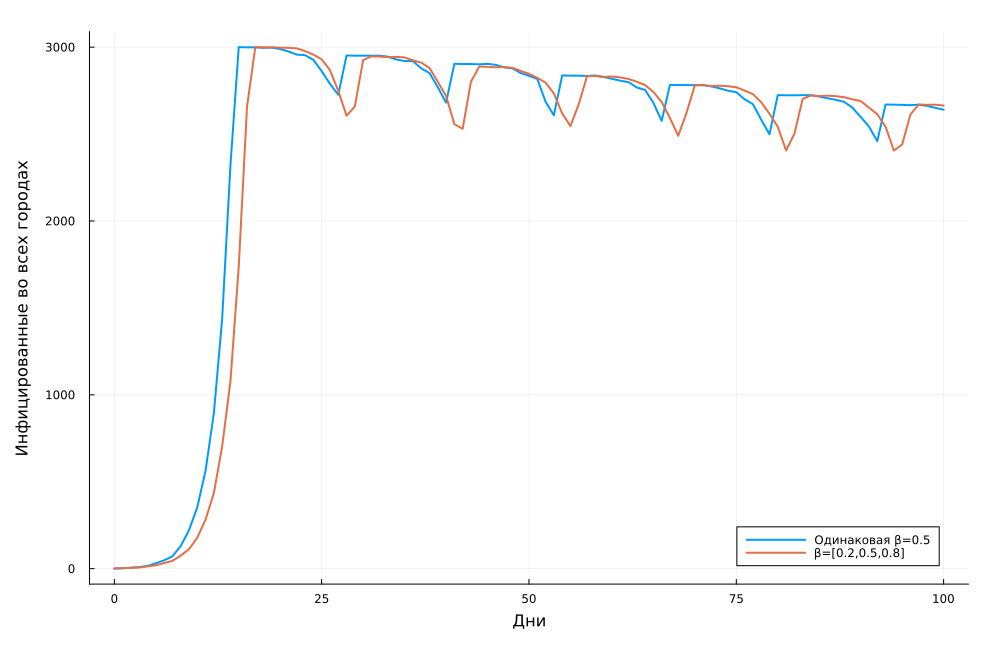

In [4]:
heterogeneous = basic_experiment(
    "sir_extra_1_2_3/heterogeneous";
    β_und = [0.2, 0.5, 0.8],
    β_det = [0.02, 0.05, 0.08],
)
panels = []
for city in 1:3
    df = heterogeneous.cities[heterogeneous.cities.city .== city, :]
    push!(
        panels,
        plot(
            df.time,
            [df.susceptible df.infected df.recovered];
            label = ["S" "I" "R"],
            title = "Город $(city)",
            xlabel = "Дни",
            ylabel = "Люди",
        ),
    )
end
figure = plot(panels...; layout = (3, 1), size = (1000, 1100))
savefig(figure, imagefile("11-plot.png"))
display(figure)
figure = plot(
    baseline.time,
    baseline.infected;
    label = "Одинаковая β=0.5",
    xlabel = "Дни",
    ylabel = "Инфицированные во всех городах",
)
plot!(
    figure,
    heterogeneous.df.time,
    heterogeneous.df.infected;
    label = "β=[0.2,0.5,0.8]",
)
savefig(figure, imagefile("12-plot.png"))
display(figure)

Формула R₀=β/γ здесь является ориентиром из задания. В агентной модели
заразность меняется после выявления, есть миграция и повторное заражение,
поэтому совпадение эмпирического порога с простым ОДУ не предполагается.